# -------DATA CLEANING-------

## -------DATA INSPECTION-------

In [209]:
import pandas as pd
import matplotlib.pyplot as plt

In [210]:
df = pd.read_csv("messy_customer_sales_data.csv")
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,m,52.0,KOLKATA,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,India
1,CUST5957,Jason Thomas,M,51.0 years,NaN,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,F,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,India
3,CUST2934,Brenda Pierce,FEMALE,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,f,41.0,CHENNAI,2024-04-05,2024-12-15,NaN,8.0,denise84@example.org,2665569480,India
...,...,...,...,...,...,...,...,...,...,...,...,...
10195,CUST10767,Robert Lewis,female,35.0 years,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,InDia
10196,NaN,Diane Evans,M,53.0,bangalore,2023-12-31,2025-05-07,11639.0,7.0,lisadennis@example.net,5200349941,IND
10197,CUST6315,Joshua Martinez,m,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,India
10198,CUST4812,Sarah Miller,FEMALE,55.0,NaN,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,InDia


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                10200 non-null  object 
 2   Gender              9174 non-null   object 
 3   Age                 9249 non-null   object 
 4   City                9184 non-null   object 
 5   Signup_Date         10200 non-null  object 
 6   Last_Purchase_Date  9188 non-null   object 
 7   Purchase_Amount     9179 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               10200 non-null  object 
 10  Phone_Number        10200 non-null  int64  
 11  Country             9468 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 956.4+ KB


### Problem inspected from above are:
      1. Datatypes
        - Age should have integer Dtype
        - Signup_Date should have date & time Dtype
        - Last_Purchase_Date should have date & time Dtype 

In [212]:
df.describe().round() #Summary Statistics Techniques

,Purchase_Amount,Feedback_Score,Phone_Number
count,9179.0,9177.0,1.020000e+04
mean,29090.0,5.0,4.979974e+09
std,208697.0,3.0,2.902593e+09
min,-500.0,1.0,9.208990e+05
25%,12295.0,3.0,2.449157e+09
50%,24330.0,5.0,4.988639e+09
75%,37130.0,8.0,7.510448e+09
max,9999999.0,10.0,9.994402e+09


### Problems inspected from above are:
      1. Outliers
        - in purchase amount, it can be seen the max is more above than mean value. So, it is outlier

In [213]:
df.isnull().sum() #Check for missing values

Customer_ID           1023
Name                     0
Gender                1026
Age                    951
City                  1016
Signup_Date              0
Last_Purchase_Date    1012
Purchase_Amount       1021
Feedback_Score        1023
Email                    0
Phone_Number             0
Country                732
dtype: int64

In [214]:
df.shape

(10200, 12)

### Problems inspected from above are:
      1. Null Values from 10200 records
      
          Customer_ID           1023
          Name                     0
          Gender                1026
          Age                    951
          City                  1016
          Signup_Date              0
          Last_Purchase_Date    1012
          Purchase_Amount       1021
          Feedback_Score        1023
          Email                    0
          Phone_Number             0
          Country                732

In [215]:
df.isnull().sum()/len(df)*100 #Percentage of missing values

Customer_ID           10.029412
Name                   0.000000
Gender                10.058824
Age                    9.323529
City                   9.960784
Signup_Date            0.000000
Last_Purchase_Date     9.921569
Purchase_Amount       10.009804
Feedback_Score        10.029412
Email                  0.000000
Phone_Number           0.000000
Country                7.176471
dtype: float64

In [216]:
df.dropna().shape

(4528, 12)

### Note: We have more missing values in several columns. We can drop the columns but dropping the columns may leas loss of numbers of records. We can shee above after dropping we have 4528 records i.e 60% of data we have lost. So, directly dropping the columns is not a good idea.

In [217]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10195    False
10196    False
10197    False
10198    False
10199    False
Length: 10200, dtype: bool

In [218]:
df[df.duplicated()].shape

(15, 12)

In [219]:
df[df.duplicated()] #Check for duplicate records

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2032,CUST2755,Casey Campbell,male,NaN,Hyderabad,2023-12-01,2024-11-04,11778.0,3.0,joseph49@example.com,3844741384,India
3191,NaN,Travis Schneider,f,51.0,NaN,2025-04-20,2025-02-28,48750.0,5.0,bianca77@example.net,7623118785,India
4312,CUST8305,Stanley Cain,FEMALE,51.0,Bangalore,2023-08-14,2024-11-01,11432.0,6.0,calderonbrenda@example.org,4889366037,India
5611,CUST6288,Jonathon Kim,male,46.0,Chennai,2023-11-22,2025-03-21,3301.0,6.0,tparker@example.com,5266662560,India
5680,CUST2695,Lisa Durham,NaN,46.0,Chennai,2021-04-18,2024-10-10,6511.0,3.0,andrew34@example.com,2235480149,India
5899,CUST8841,Amanda Hill,NaN,34.0,chennai,2022-09-11,2025-03-13,42092.0,4.0,ryanriley@example.net,3466026146,India
6070,CUST10780,Emily Smith,NaN,23.0,Kolkata,2023-12-09,2024-10-28,18027.0,5.0,perezchristopher@example.com,3032282870,India
6240,CUST9745,David Morales,NaN,56.0,NaN,2023-02-18,2024-12-14,49107.0,7.0,juliaknapp@example.com,9436163110,India
6425,CUST4631,George Villa,m,26.0,Mumbai,2022-05-21,2025-06-17,NaN,8.0,davidmarquez@example.com,8869465862,India
6498,CUST1711,Stephanie Elliott,NaN,44.0,MUMBAI,2023-05-17,2025-07-12,11349.0,9.0,nfischer@example.com,3270872546,NaN


## Problems inspected from above are:
  1. Duplicate records
    - There are 15 rows and 12 columns with duplicates value

In [220]:
df['Customer_ID'].value_counts() #Check for duplicate records in a specific column

Customer_ID
CUST3374     2
CUST7749     2
CUST10800    2
CUST6588     2
CUST9062     2
            ..
CUST10204    1
CUST4647     1
CUST9548     1
CUST9966     1
CUST4812     1
Name: count, Length: 9000, dtype: int64

### Since, Customer_ID is unique, it's duplicate value show duplicate record(row). And using the function value_counts that gives frequency of data, duplicate records have generated above

In [221]:
df[df['Customer_ID'] == 'CUST3374']

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
2914,CUST3374,Timothy Wallace,m,58.0,Bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India
3047,CUST3374,Timothy Wallace,m,58.0,bangalore,2024-03-08,2025-08-21,45779.0,1.0,glenn95@example.org,9687701793,India


### Note: There were 15 duplicate rows/records, but these rows were not detected initially because the records had inconsistent formatting. For example, rows 2914 and 3047 contain the same records, but the first letter in the City column has a different case. The earlier function detected these as different records according to the letter case in city column, but it got identified as duplicates when frequency counts were applied. These row has more inconsistencies.

In [222]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print("-"*50)

Gender
f         1184
M         1171
m         1163
F         1157
MALE      1131
female    1128
male      1121
FEMALE    1119
Name: count, dtype: int64
--------------------------------------------------
City
Kolkata       820
Mumbai        812
Chennai       784
Bangalore     773
Hyderabad     770
Delhi         763
CHENNAI       404
KOLKATA       395
MUMBAI        393
hyderabad     384
bangalore     383
DELHI         378
delhi         369
BANGALORE     363
HYDERABAD     360
mumbai        352
chennai       343
kolkata       338
Name: count, dtype: int64
--------------------------------------------------
Feedback_Score
2.0     952
4.0     947
7.0     938
6.0     927
3.0     913
8.0     912
1.0     907
9.0     903
10.0    901
5.0     877
Name: count, dtype: int64
--------------------------------------------------
Country
India    7132
IND       793
india     772
InDia     771
Name: count, dtype: int64
--------------------------------------------------


### Data Inspection from above code
  ### The above output shows the inconsistencies in categorical data present in gender, city and country columns.

## ----------DATA CLEANING----------

## -------Handling Missing Data------

In [223]:
df.dropna(subset = ['Customer_ID'], inplace = True)
df.isnull().sum()
# This drops all row with missing values in the 'Customer_ID' column.
# Because 'Customer_ID' is a unique identifier, we cannot have missing values in this column.

Customer_ID             0
Name                    0
Gender                934
Age                   859
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount       927
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [224]:
df['Age'].apply(lambda x: re.findall('[0-9]+', str(x)))

0        [52, 0]
1        [51, 0]
2        [62, 0]
3        [40, 0]
4        [41, 0]
          ...   
10194    [40, 0]
10195    [35, 0]
10197    [25, 0]
10198    [55, 0]
10199    [34, 0]
Name: Age, Length: 9177, dtype: object

In [225]:
# import re
# for i in df['Age'].apply(lambda x: re.findall('[0-9]+', str(x))):
#     if len(i) < 2:
#         print(i)

In [226]:
import re

def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num) > 0:
        return int(age_num[0])
    else:
        return age
df['Age'] = df['Age'].apply(lambda x: extract_age(x))

In [227]:
df['Age'].unique()

array([52, 51, 62, 40, 41, nan, 18, 43, 26, 32, 22, 59, 65, 61, 31, 54,
       55, 69, 24, 63, 19, 50, 56, 36, 68, 38, 27, 57, 23, 25, 66, 28, 30,
       46, 48, 20, 37, 67, 35, 58, 29, 'nan years', 39, 49, 47, 42, 44,
       64, 53, 60, 45, 21, 34, 33, 250, 3, 10], dtype=object)

### Let's decode the above code:

The value of each row in the Age column is passed to the lambda function. The lambda function then calls the extract_age() function, passing x (i.e., each value from the Age column) as an argument.

Inside the extract_age() function, the re.findall('[0-9]+', str(age)) function searches for numeric values. [0-9] matches any digit from 0 to 9, while + allows it to match one or more consecutive digits. For example, if the value is 23-58, findall() returns ['23', '58'].

In the if condition, we check whether at least one number was found. If a number exists, age_num[0] retrieves the value at index 0, which is the first number found. In this dataset, the first number represents the actual age, so we convert it to an integer and return it.

Note: The .apply() function takes each value from the Age column and passes it to the lambda function.

### Problem in Age column
It is clearly seen that the there is two unique value i.e. nan and nan years is interrupting. So, the value can be replaced with median but the data has object dtype.

So, first it needs to be converted into int datatype then median can be calculated.

In [228]:
df_age = df[df['Age'] != 'nan years']['Age']

### The above code filters the DataFrame based on the condition Age != 'nan years', meaning it keeps the rows where the Age value is not equal to the string 'nan years'. After filtering the rows, only the Age column is selected and stored in df_age.

In [229]:
df_age.unique()

array([52, 51, 62, 40, 41, nan, 18, 43, 26, 32, 22, 59, 65, 61, 31, 54,
       55, 69, 24, 63, 19, 50, 56, 36, 68, 38, 27, 57, 23, 25, 66, 28, 30,
       46, 48, 20, 37, 67, 35, 58, 29, 39, 49, 47, 42, 44, 64, 53, 60, 45,
       21, 34, 33, 250, 3, 10], dtype=object)

In [230]:
age_median = int(df_age.dropna().astype('int64').median())

### To calculate the median, the Age column must contain numeric values. Therefore, non-numeric or invalid values should first be removed or converted to missing values, and the remaining values should be converted to an integer or numeric data type. After that, the median can be calculated. So, Above code calculates median

In [231]:
df.replace('nan years', age_median, inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/4115931488.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('nan years', age_median, inplace = True)


### Above code replace value 'nan years' with age_median value.

In [232]:
df['Age'].fillna(age_median, inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/490034067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace = True)


### Above code fills null value with age_median value in age column

In [233]:
df['Age'].unique()

array([ 52.,  51.,  62.,  40.,  41.,  43.,  18.,  26.,  32.,  22.,  59.,
        65.,  61.,  31.,  54.,  55.,  69.,  24.,  63.,  19.,  50.,  56.,
        36.,  68.,  38.,  27.,  57.,  23.,  25.,  66.,  28.,  30.,  46.,
        48.,  20.,  37.,  67.,  35.,  58.,  29.,  39.,  49.,  47.,  42.,
        44.,  64.,  53.,  60.,  45.,  21.,  34.,  33., 250.,   3.,  10.])

### Note: we can see the outlier i.e. Age value 250

In [234]:
df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/1105428469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Purchase_Amount'].fillna(df['Purchase_Amount'].median(), inplace = True)


In [235]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                934
Age                     0
City                  918
Signup_Date             0
Last_Purchase_Date    914
Purchase_Amount         0
Feedback_Score        905
Email                   0
Phone_Number            0
Country               664
dtype: int64

In [236]:
df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/1221350052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Feedback_Score'].fillna(df['Feedback_Score'].mode()[0], inplace = True)


### Since the Feedback_Score is a discrete value, the mode has been used to replace the null values in the Feedback_Score column.

In [237]:
for col in ['Gender', 'City', 'Country']:
    df[col].fillna(df[col].mode()[0], inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/1551703587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace = True)


### since Gender, City and Country are categorical variables, we can fill the missing values with the mode of the respective columns.

In [238]:
df['Last_Purchase_Date'].ffill(inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/2735699428.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_Purchase_Date'].ffill(inplace = True)


### .ffill (forward fill) has been used in above code to fill the missing value in Last_Purchase_Date. If there is a missing value, use the previous available value.

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9177 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9177 non-null   object 
 1   Name                9177 non-null   object 
 2   Gender              9177 non-null   object 
 3   Age                 9177 non-null   float64
 4   City                9177 non-null   object 
 5   Signup_Date         9177 non-null   object 
 6   Last_Purchase_Date  9177 non-null   object 
 7   Purchase_Amount     9177 non-null   float64
 8   Feedback_Score      9177 non-null   float64
 9   Email               9177 non-null   object 
 10  Phone_Number        9177 non-null   int64  
 11  Country             9177 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 932.0+ KB


## ---------Fixing Inconsistent Formatting-------------

In [240]:
df['Gender'].unique()

array(['m ', 'M', 'F', 'FEMALE', 'f ', 'male', 'MALE', 'female'],
      dtype=object)

In [241]:
df['Gender'] = df['Gender'].str.lower().str.strip()

### It is seen that above output shows 8 unique value. And applying lower to the value decreases unique value to 4.
### .strip() helps in removing leading and trailing spaces. example "  m" -> "m", "female  " -> "female"

In [242]:
df['Gender'].replace({'m': 'male', 'f': 'female'}, inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/3365504658.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'m': 'male', 'f': 'female'}, inplace = True)


### Above m and f has been replaced with male and female respectively.

In [243]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [244]:
df['City'] = df['City'].str.strip().str.lower()

### Simillarly, strip and lower function has been used here to remove inconsistencies from city column.

In [245]:
df['Country'].unique()

array(['India', 'india', 'InDia', 'IND'], dtype=object)

In [246]:
df['Country'] = df['Country'].str.lower()

In [247]:
df['Country'].unique()

array(['india', 'ind'], dtype=object)

In [248]:
df['Country'].replace({'ind': 'india'}, inplace = True)

/var/folders/m9/1l28ck590nsdm4f_0mrn7b8c0000gn/T/ipykernel_10653/2763558389.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].replace({'ind': 'india'}, inplace = True)


In [249]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52.0,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,india
1,CUST5957,Jason Thomas,male,51.0,kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,female,62.0,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,india
3,CUST2934,Brenda Pierce,female,40.0,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,female,41.0,chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,india
...,...,...,...,...,...,...,...,...,...,...,...,...
10194,CUST6146,Cody Thompson,female,40.0,kolkata,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,india
10195,CUST10767,Robert Lewis,female,35.0,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,india
10197,CUST6315,Joshua Martinez,male,25.0,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,india
10198,CUST4812,Sarah Miller,female,55.0,kolkata,2021-03-16,2025-05-14,18827.0,10.0,dawn84@example.org,2987564247,india


In [250]:
df[df.duplicated()].shape

(163, 12)

In [251]:
df.drop_duplicates(inplace = True)

### Again duplicate value got dropped

In [252]:
df['Customer_ID'].value_counts()

Customer_ID
CUST9534    2
CUST4196    2
CUST5341    2
CUST2510    2
CUST1002    2
           ..
CUST7618    1
CUST2436    1
CUST5982    1
CUST5432    1
CUST4812    1
Name: count, Length: 9000, dtype: int64

In [253]:
df.drop_duplicates(subset = ['Customer_ID'], keep = 'first', inplace = True)

### Still there were duplicates value in Customer_ID so, it got removed except first duplicate. i.e 1. ram and 2. ram -> 1. ram(first remains as it is)

In [254]:
df.shape

(9000, 12)

## -------Correcting Data Types----------

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         9000 non-null   object 
 1   Name                9000 non-null   object 
 2   Gender              9000 non-null   object 
 3   Age                 9000 non-null   float64
 4   City                9000 non-null   object 
 5   Signup_Date         9000 non-null   object 
 6   Last_Purchase_Date  9000 non-null   object 
 7   Purchase_Amount     9000 non-null   float64
 8   Feedback_Score      9000 non-null   float64
 9   Email               9000 non-null   object 
 10  Phone_Number        9000 non-null   int64  
 11  Country             9000 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 914.1+ KB


In [256]:
df['Age'] = df['Age'].astype('int64')

In [257]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])

In [258]:
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

### Age, Last_Purchase_Date and Signup_Date had object datatype. So, it got changed according to rellevant datatype.

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9000 entries, 0 to 10198
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         9000 non-null   object        
 1   Name                9000 non-null   object        
 2   Gender              9000 non-null   object        
 3   Age                 9000 non-null   int64         
 4   City                9000 non-null   object        
 5   Signup_Date         9000 non-null   datetime64[ns]
 6   Last_Purchase_Date  9000 non-null   datetime64[ns]
 7   Purchase_Amount     9000 non-null   float64       
 8   Feedback_Score      9000 non-null   float64       
 9   Email               9000 non-null   object        
 10  Phone_Number        9000 non-null   int64         
 11  Country             9000 non-null   object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 914.1+ KB


## ----------- Handling Outliers --------------

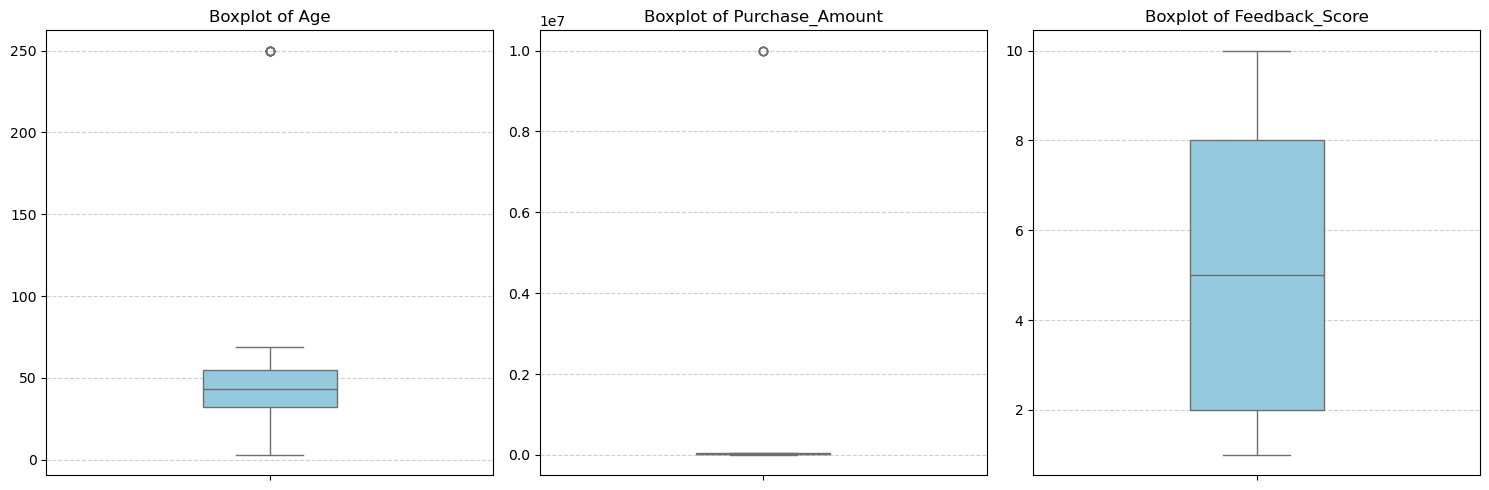

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

plt.figure(figsize = (15,5))
for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y = df[col], color = 'skyblue', width = 0.3)
    plt.title(f'Boxplot of {col}', fontsize = 12)
    plt.ylabel('')
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()


## from diagram we can see outliers in Age and purchase_amount. Small dot above in the figure shows outliers.

In [261]:
from scipy import stats
import numpy as np

In [262]:
z_scores =np.abs(stats.zscore(df[['Age','Purchase_Amount']]))

### calculates zscore for age,and purchase_amount column

In [268]:
df_clean = df[~(z_scores > 3).any(axis = 1)]

# The above code filters the records not having zscores > 3 in age or purchase_amount column

In [270]:
df_clean.shape

(8989, 12)

# Now, the data is completely cleaned